<a href="https://colab.research.google.com/github/nroselnik/Counting-ratbones-from-owl-pukes/blob/master/Completed_new_version_of_rat_population_from_owl_puke_using_YOLOV11_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Train YOLO11 Object Detection on a Custom Dataset**

# **Install Ultralytics**

In [ ]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.6/914.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.3 MB/s eta 0:00:00


# **Import all necessary Libraries**

In [ ]:
from ultralytics import YOLO
from IPython.display import Image,display

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## **Download Dataset From Roboflow**

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="WHlikUw1LTzMHaG9KG1V")
project = rf.workspace("ml-usm").project("updated-rat-bone-v2")
version = project.version(2)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


# **Custom Training**

In [ ]:
!yolo task=detect mode=train model=yolo11n.pt data=/content/Updated-Rat-Bone-V2/data.yaml epochs=80 imgsz=640 plots=True

Ultralytics 8.3.73 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Updated-Rat-Bone-V2/data.yaml, epochs=80, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=Tru

# **View Training Results**

In [ ]:
display(Image(filename='/content/runs/detect/train4/results.png', width=600))

NameError: name 'Image' is not defined

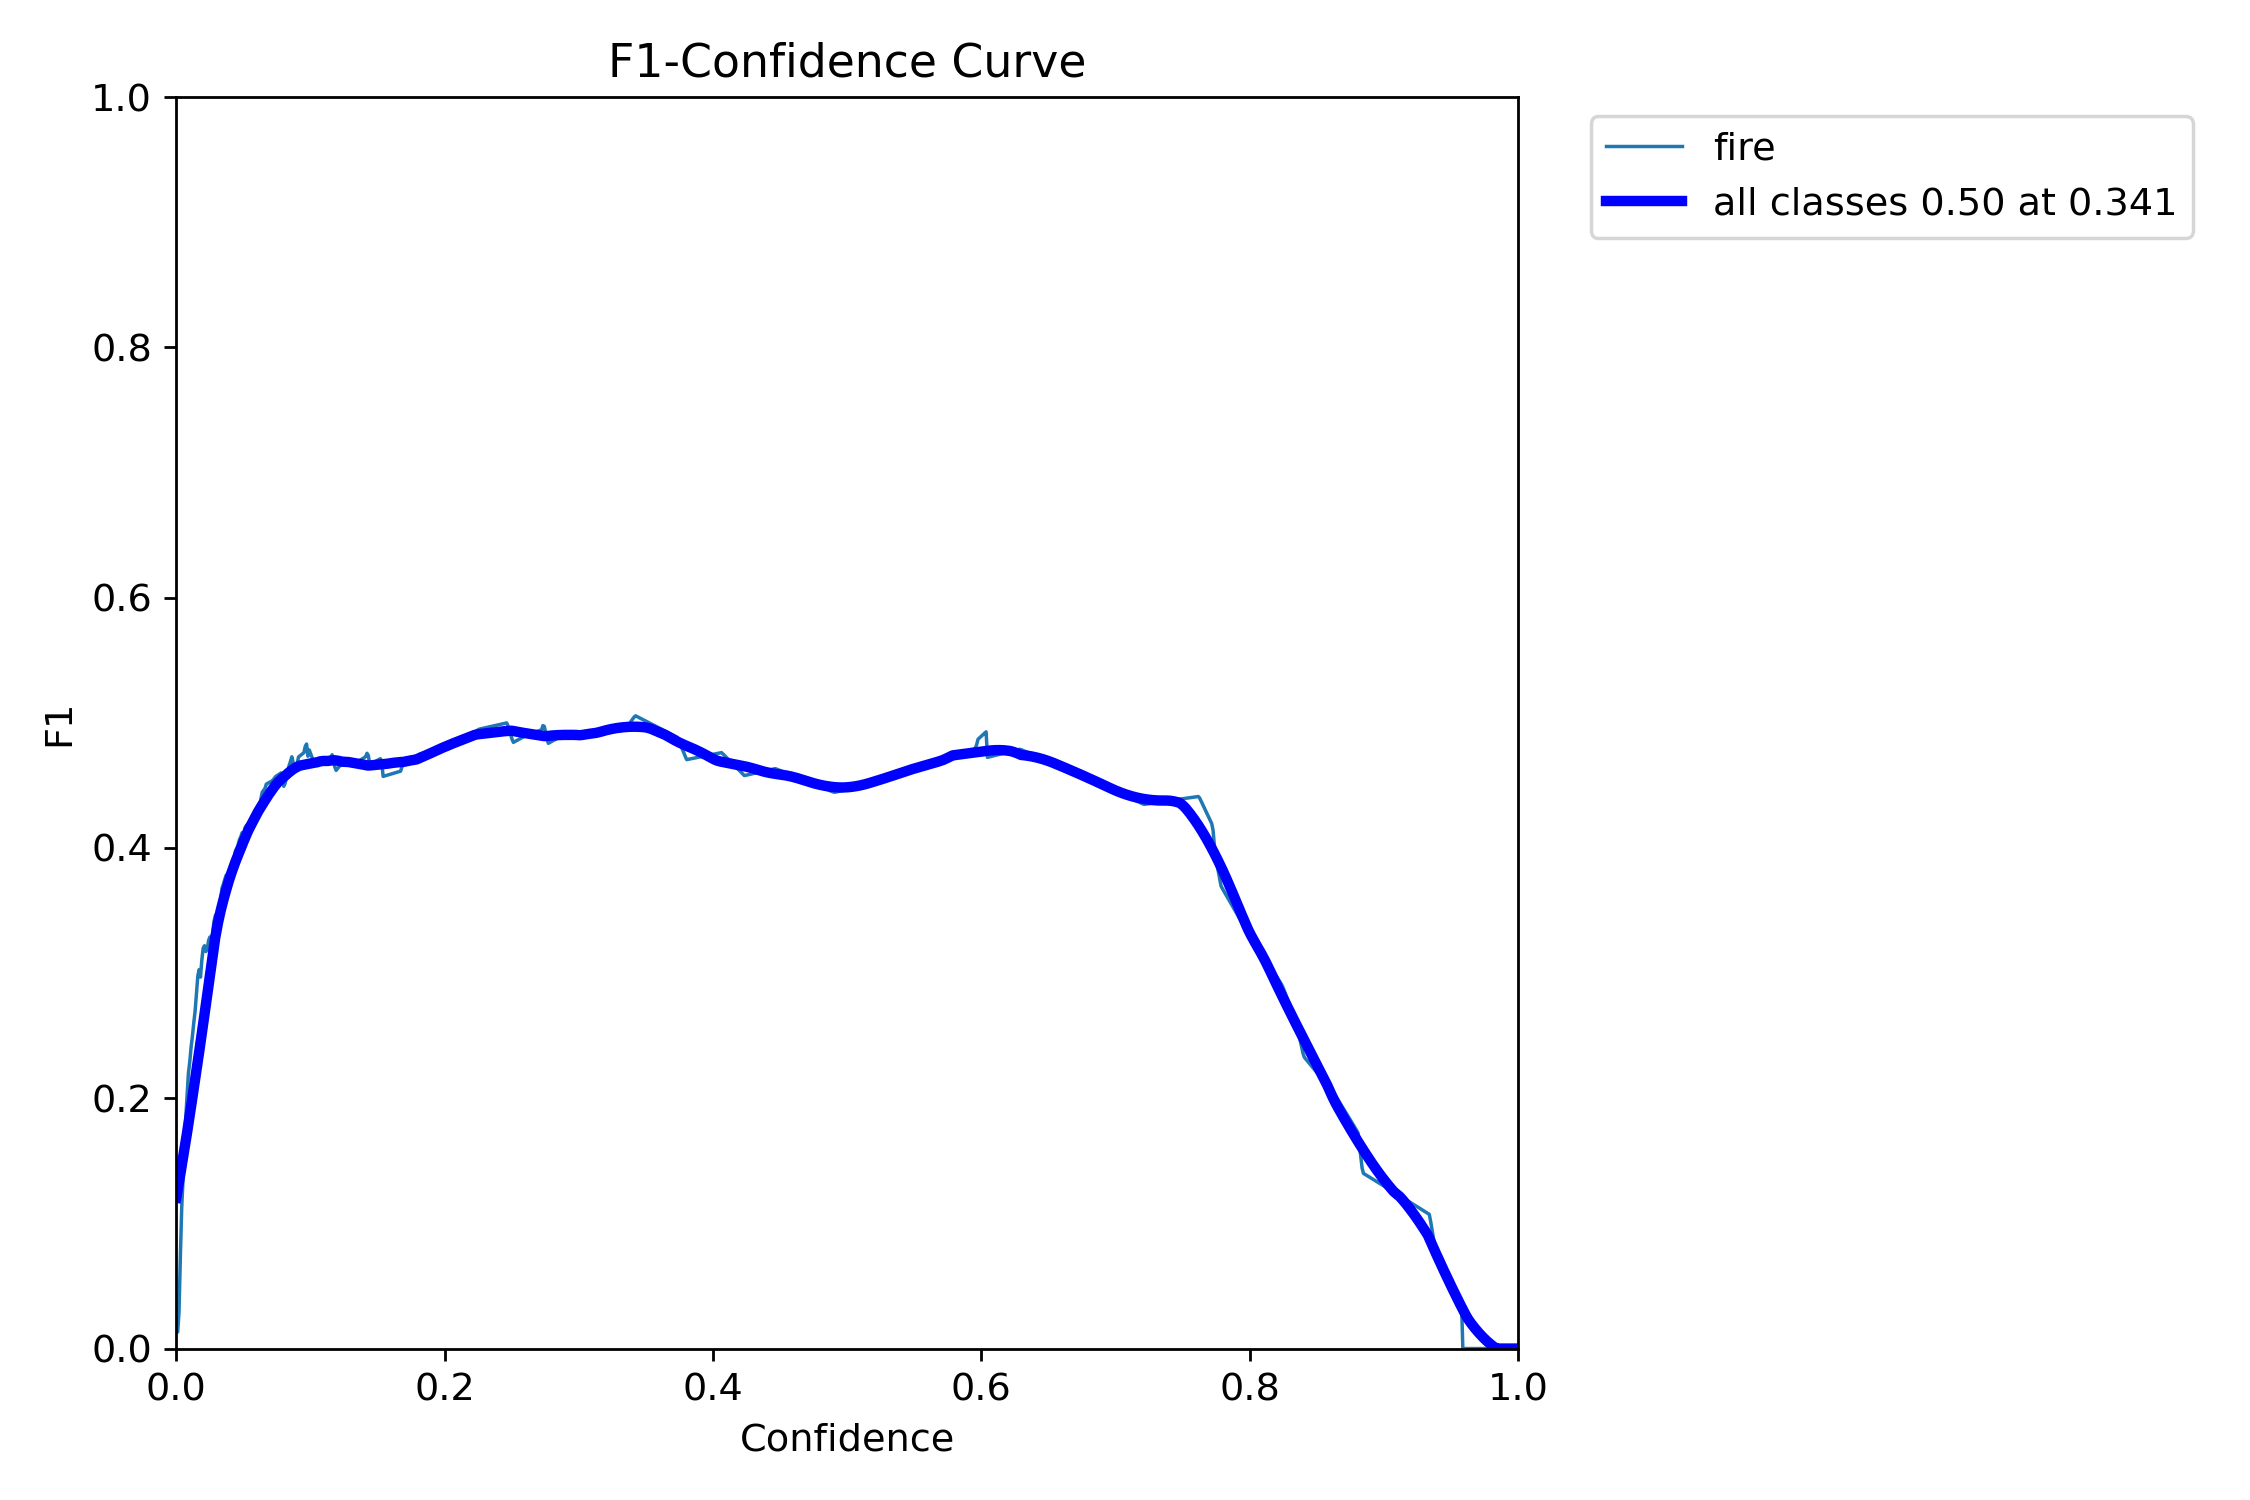

In [ ]:
display(Image(filename='/content/runs/detect/train/F1_curve.png', width=600))

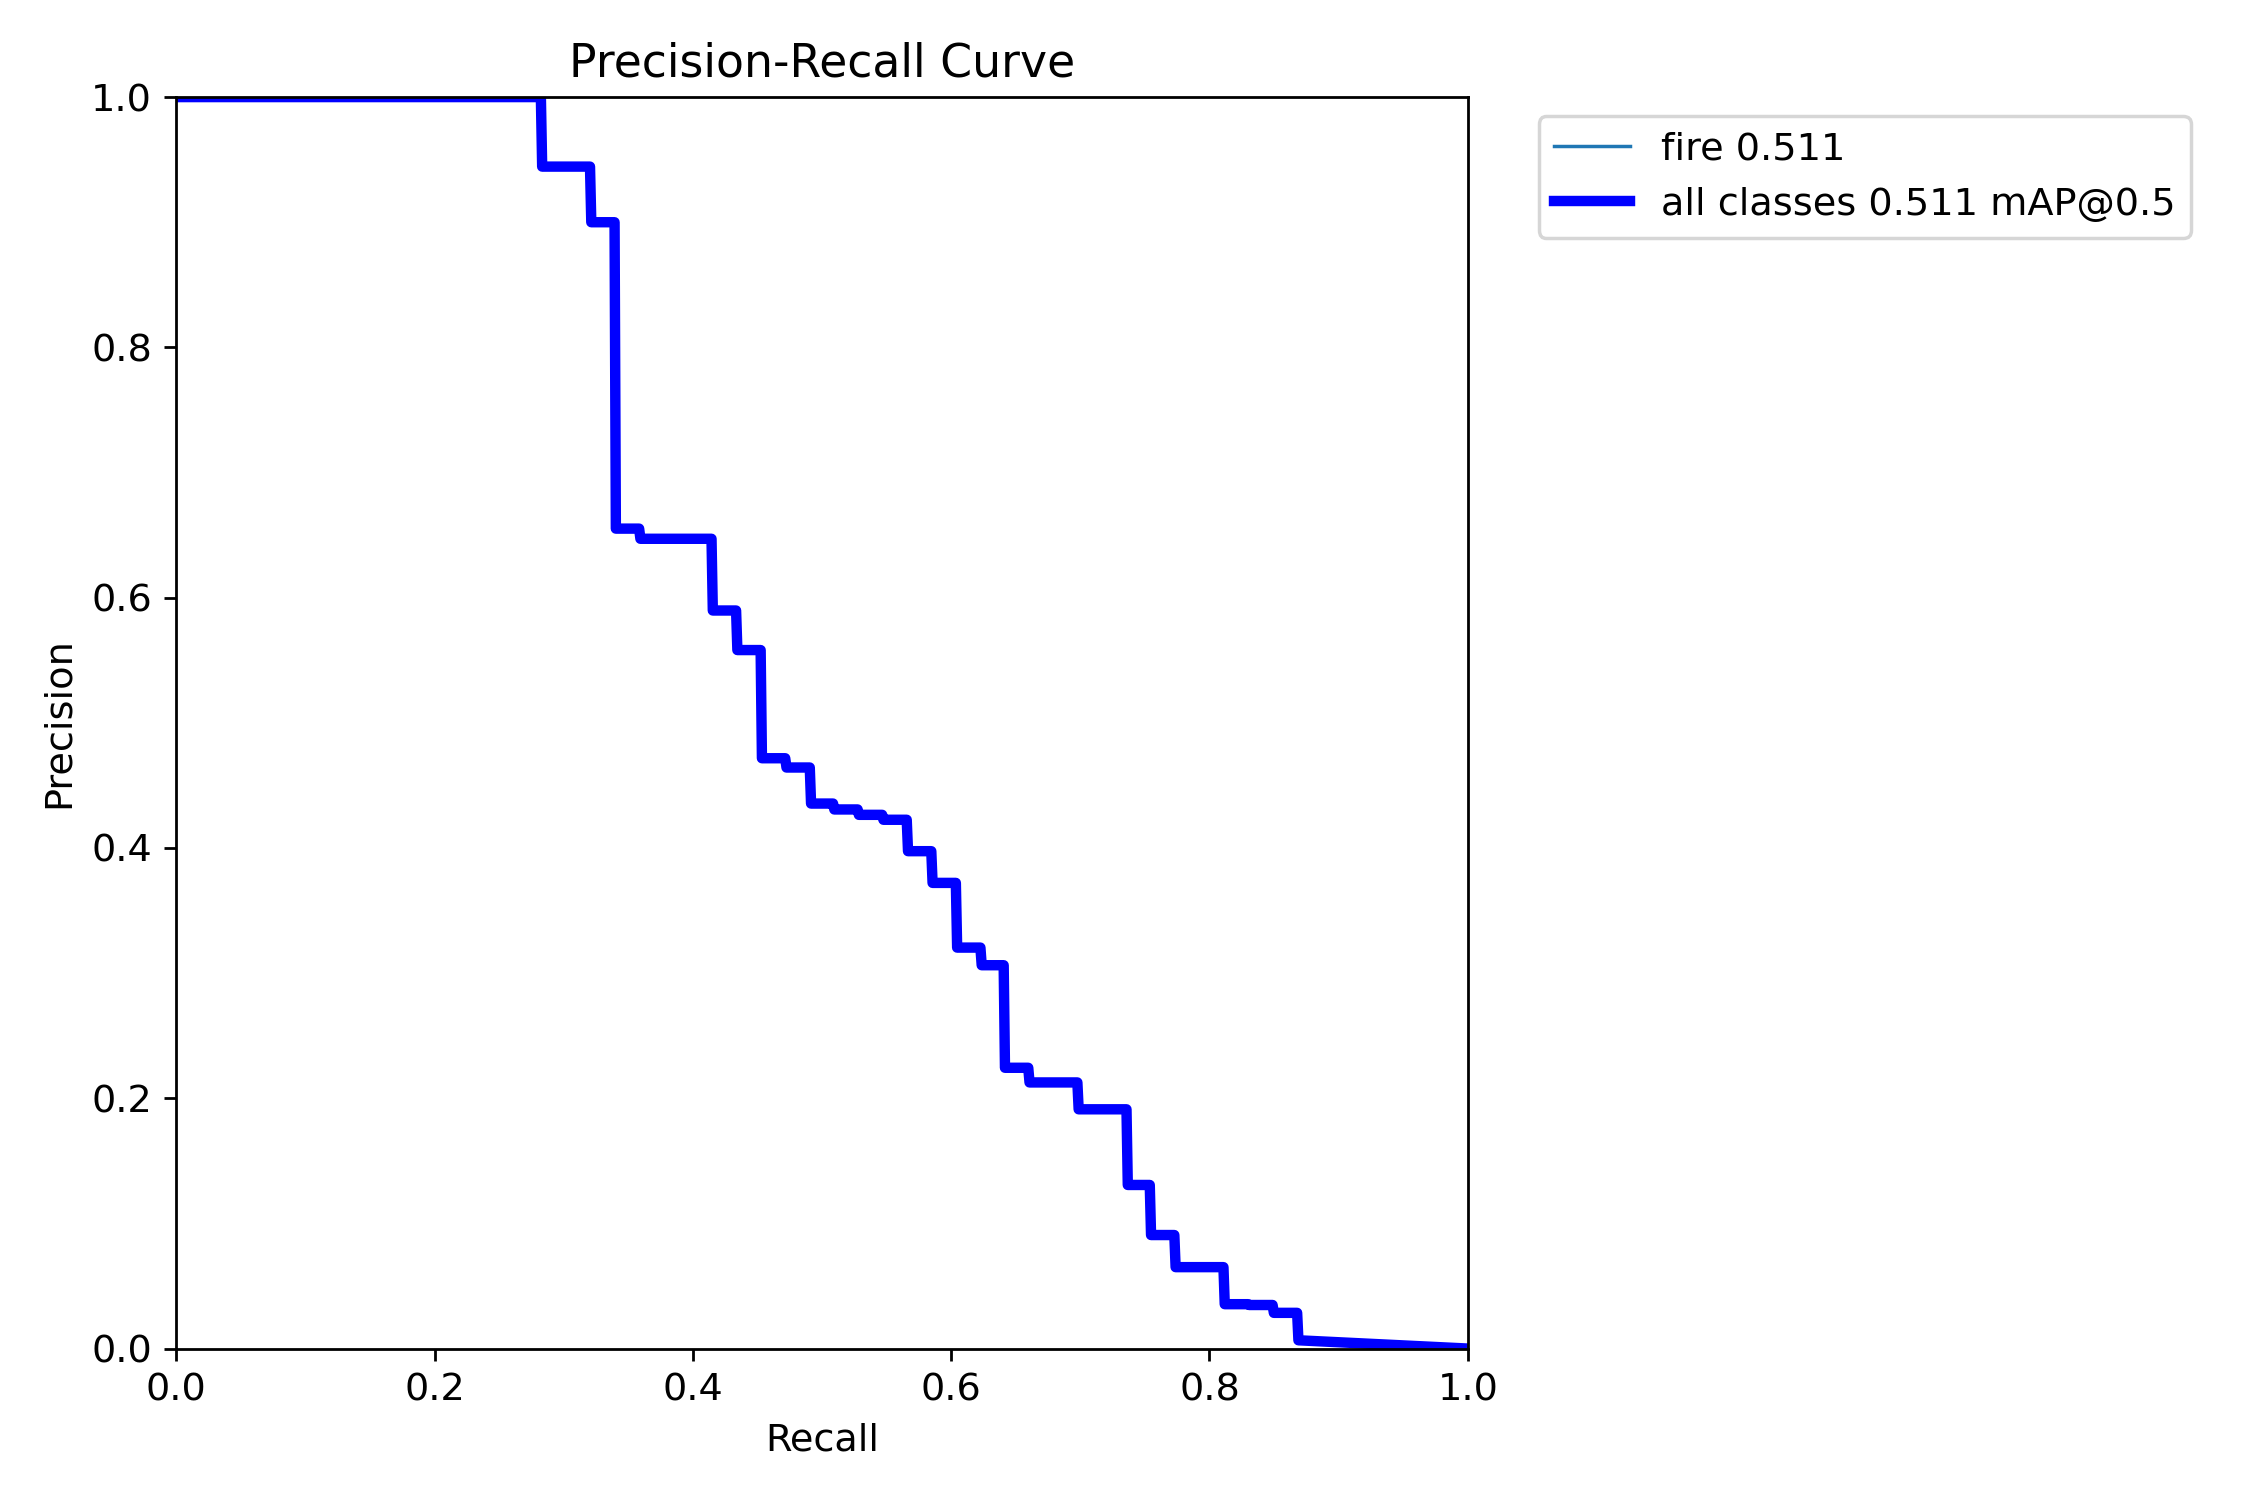

In [ ]:
display(Image(filename='/content/runs/detect/train/PR_curve.png', width=600))

### **Validate fine-tuned model**

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train4/weights/best.pt data=/content/Updated-Rat-Bone-V2/data.yaml

Ultralytics 8.3.73 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /content/Updated-Rat-Bone-V2/valid/labels.cache... 46 images, 0 backgrounds, 0 corrupt: 100% 46/46 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 3/3 [00:02<00:00,  1.30it/s]
                   all         46        559      0.942      0.977      0.977      0.787
                 Femur         32        210      0.953      0.976      0.982      0.728
              Mandible         26        110      0.947      0.991      0.981      0.775
                 Pubis         29        190      0.995       0.98      0.994      0.796
                 Skull         18         49      0.873      0.959      0.951      0.849
Speed: 0.4ms preprocess, 18.2ms inference, 0.0ms loss, 5.5ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at http

# **Inference with custom model**

In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train4/weights/best.pt conf=0.25 source=/content/Updated-Rat-Bone-V2/valid/images save=True

Ultralytics 8.3.73 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs

image 1/46 /content/Updated-Rat-Bone-V2/valid/images/IMG_20231215_090857-jpg-4kdomvvk-ingestion-745476759f-74c86_jpg.rf.0e5763eaae80f37bdb03dd13792d9ed7.jpg: 480x640 12 Femurs, 2 Mandibles, 18 Pubiss, 42.2ms
image 2/46 /content/Updated-Rat-Bone-V2/valid/images/IMG_20231215_092141-jpg-4kdomvv8-ingestion-745476759f-h4ngh_jpg.rf.4ad8a2673253e926435204df6ca72c28.jpg: 480x640 10 Femurs, 3 Mandibles, 10 Pubiss, 9.1ms
image 3/46 /content/Updated-Rat-Bone-V2/valid/images/IMG_20231222_102819-jpg-4kdomuum-ingestion-745476759f-qlftj_jpg.rf.82af1cdc1a7be9871b855e41de00d9bf.jpg: 480x640 5 Femurs, 3 Pubiss, 2 Skulls, 9.6ms
image 4/46 /content/Updated-Rat-Bone-V2/valid/images/IMG_20231222_102836-jpg-4kdomvag-ingestion-745476759f-qlftj_jpg.rf.0befa50185c04daedb64d35f887a2677.jpg: 480x640 5 Femurs, 3 Mandibles, 1 Pubis, 3 Skulls, 8.6ms
ima

This next code saves the classification output as txt so that we can calculate the bone numbers and predict the rat population.
Be very careful with predict file name. If you ran several inferences, the numbers will also increase, for example predict1, predict2, predict3, predict4 and so on. Always look at the last line
Results saved to runs/detect/*predict4*

In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train4/weights/best.pt conf=0.25 source=/content/Updated-Rat-Bone-V2/valid/images save=True save_txt=True


Ultralytics 8.3.73 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs

image 1/46 /content/Updated-Rat-Bone-V2/valid/images/IMG_20231215_090857-jpg-4kdomvvk-ingestion-745476759f-74c86_jpg.rf.0e5763eaae80f37bdb03dd13792d9ed7.jpg: 480x640 12 Femurs, 2 Mandibles, 18 Pubiss, 44.6ms
image 2/46 /content/Updated-Rat-Bone-V2/valid/images/IMG_20231215_092141-jpg-4kdomvv8-ingestion-745476759f-h4ngh_jpg.rf.4ad8a2673253e926435204df6ca72c28.jpg: 480x640 10 Femurs, 3 Mandibles, 10 Pubiss, 9.1ms
image 3/46 /content/Updated-Rat-Bone-V2/valid/images/IMG_20231222_102819-jpg-4kdomuum-ingestion-745476759f-qlftj_jpg.rf.82af1cdc1a7be9871b855e41de00d9bf.jpg: 480x640 5 Femurs, 3 Pubiss, 2 Skulls, 14.3ms
image 4/46 /content/Updated-Rat-Bone-V2/valid/images/IMG_20231222_102836-jpg-4kdomvag-ingestion-745476759f-qlftj_jpg.rf.0befa50185c04daedb64d35f887a2677.jpg: 480x640 5 Femurs, 3 Mandibles, 1 Pubis, 3 Skulls, 8.9ms
im

This next code
reads detected objects from YOLO’s output.
Summarizes the detected bone counts.
Computes the minimum and maximum estimated rat populations based on skull count and surplus bones.

In [ ]:
import os
from collections import Counter

# Path to the folder where YOLO saves detection results
results_folder = "/content/runs/detect/predict4/labels"  # Update if necessary

# Initialize a counter for detected objects
object_counter = Counter()

# Loop through each text file in the results folder
for txt_file in os.listdir(results_folder):
    if txt_file.endswith(".txt"):
        with open(os.path.join(results_folder, txt_file), "r") as f:
            for line in f:
                object_id = int(line.split()[0])  # Assuming class ID is the first value
                object_counter[object_id] += 1

# Map class IDs to object names (Update according to your dataset)
class_names = {0: "femur", 1: "mandible", 2: "pubis", 3: "skull"}  # Adjust class IDs as needed

# Detected bone counts
bone_counts = {class_names[class_id]: count for class_id, count in object_counter.items()}

# Display summary of detected bones
print("Detected Bones Summary:")
for bone, count in bone_counts.items():
    print(f"{bone.capitalize()}: {count} detections")

# Bones per rat
rat_bones = {
    "skull": 1,
    "pubis": 2,
    "femur": 2,
    "mandible": 2
}

# Step 1: Minimum Estimate
# Based solely on the definitive count of skulls
min_estimate = bone_counts.get("skull", 0)

# Step 2: Surplus Calculations for Each Bone Type
surpluses = {}
for bone, count in bone_counts.items():
    if bone != "skull":  # Skulls are definitive, no surplus for skulls
        surpluses[bone] = (count // rat_bones[bone]) - min_estimate

# Step 3: Calculate Maximum Estimate
# Add all possible surpluses to the skull count
max_estimate = min_estimate + sum(surplus for surplus in surpluses.values() if surplus > 0)

# Step 4: Print Results
print("\nEstimated Number of Rats Per Class:")
for bone, surplus in surpluses.items():
    estimated_rats = min_estimate + max(0, surplus)
    print(f"{bone.capitalize()} Estimate: {estimated_rats} rats")

print(f"\nMinimum Estimated Population (based on skulls): {min_estimate}")
print(f"Maximum Estimated Population (assuming no overlap): {max_estimate}")


Detected Bones Summary:
Femur: 240 detections
Pubis: 206 detections
Mandible: 135 detections
Skull: 54 detections

Estimated Number of Rats Per Class:
Femur Estimate: 120 rats
Pubis Estimate: 103 rats
Mandible Estimate: 67 rats

Minimum Estimated Population (based on skulls): 54
Maximum Estimated Population (assuming no overlap): 182


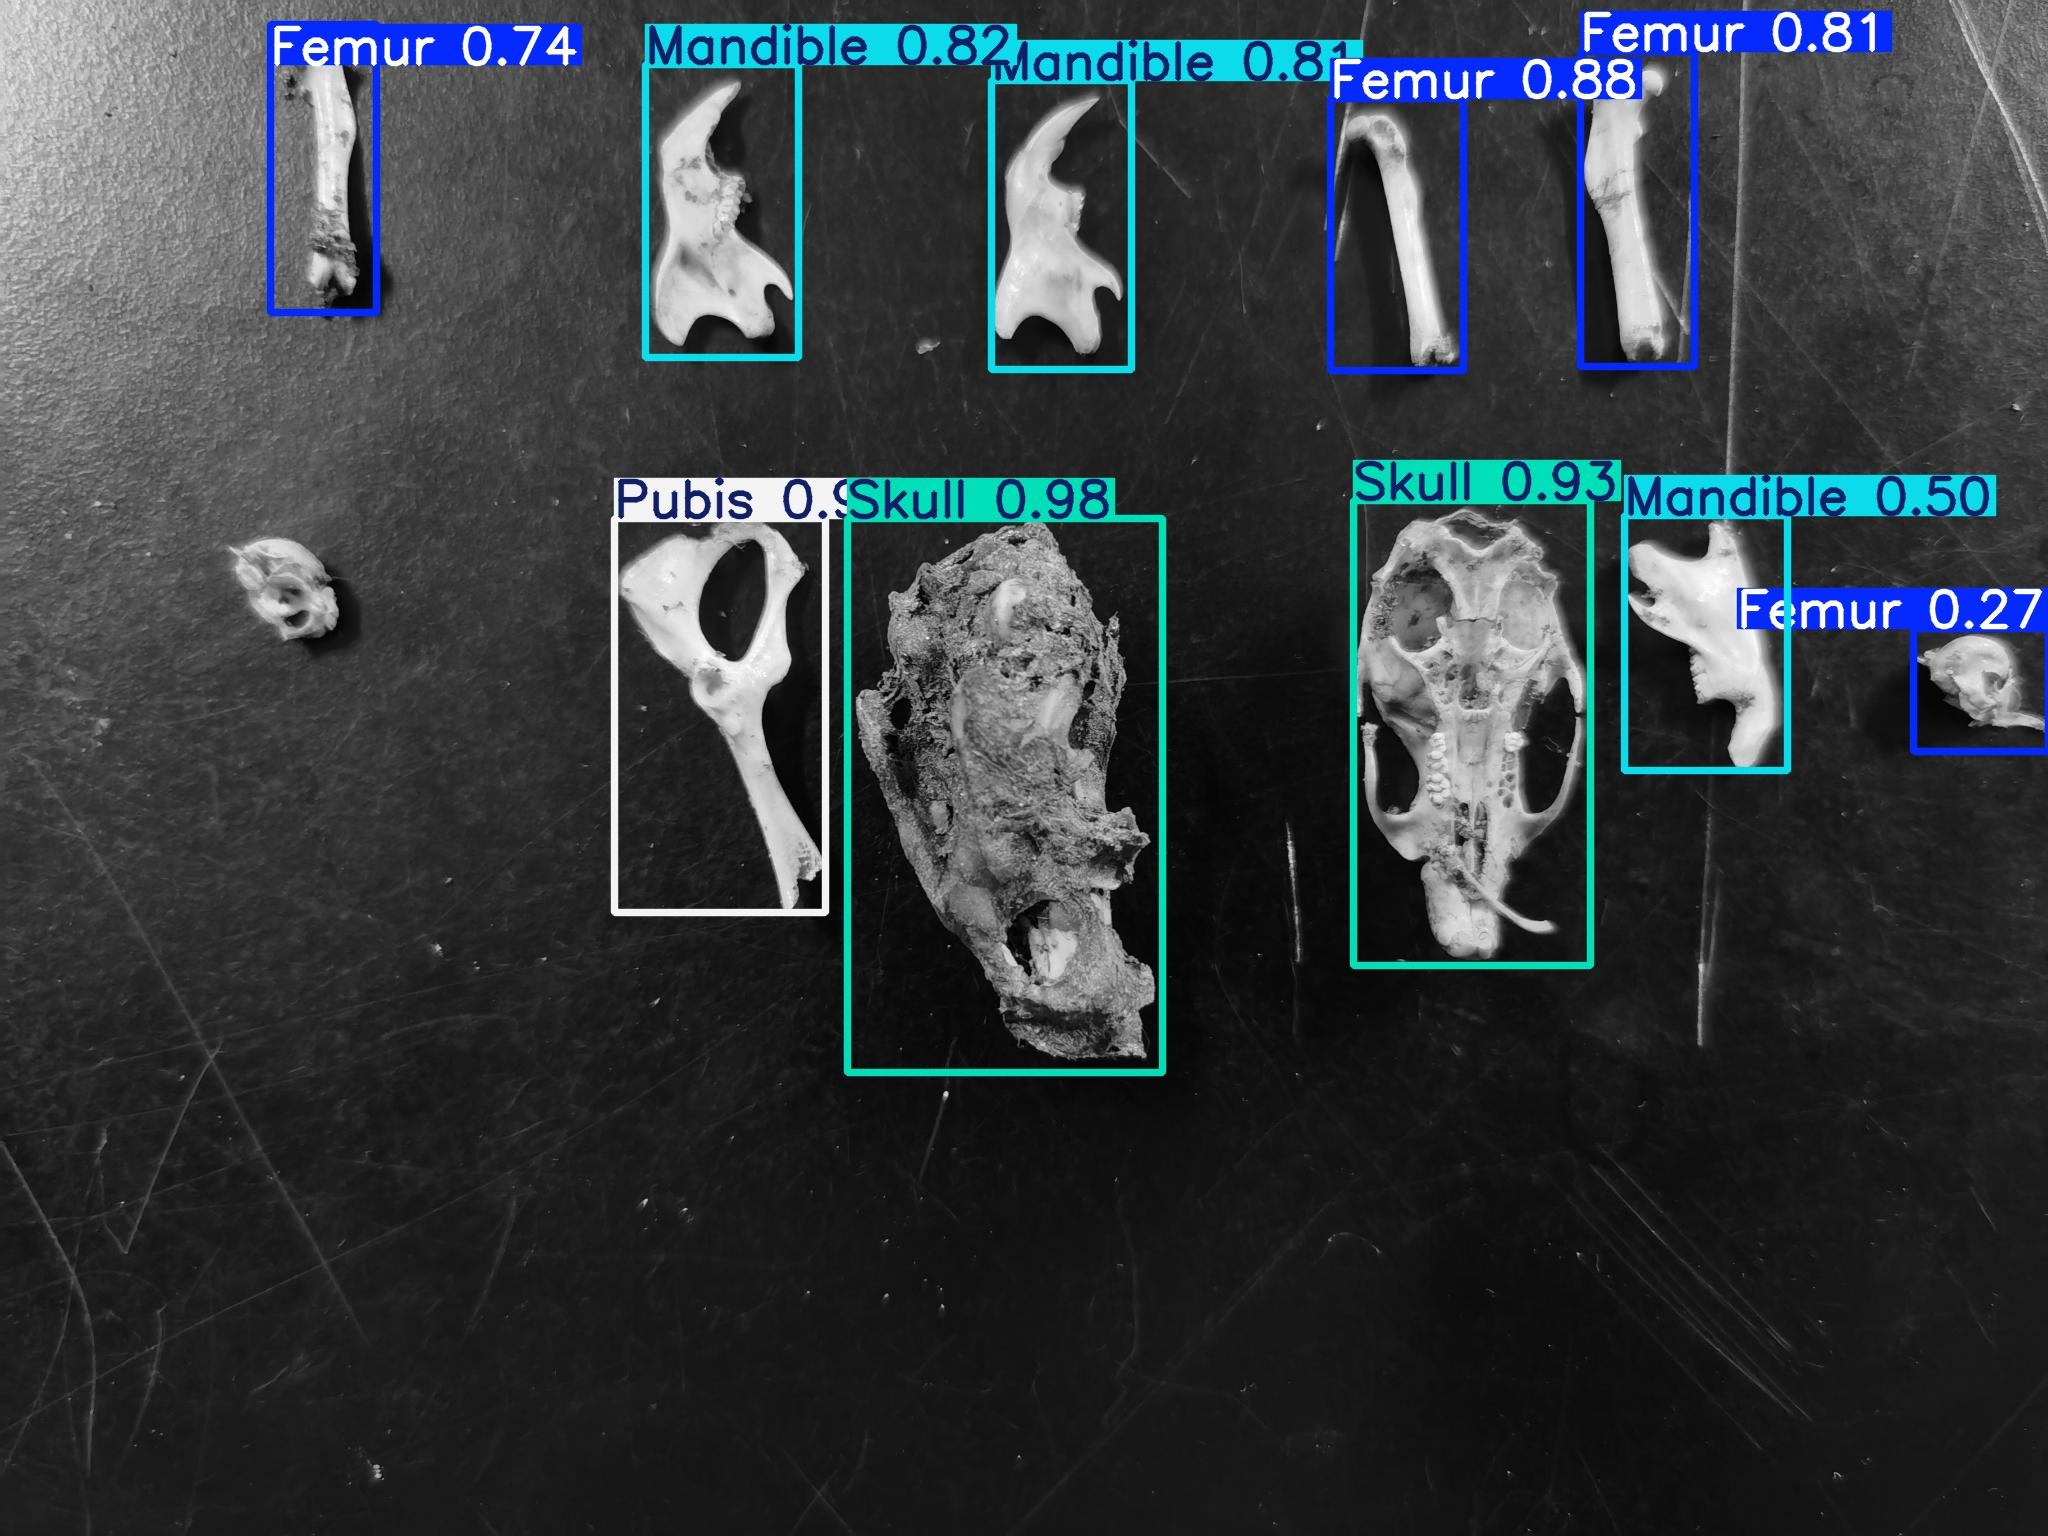

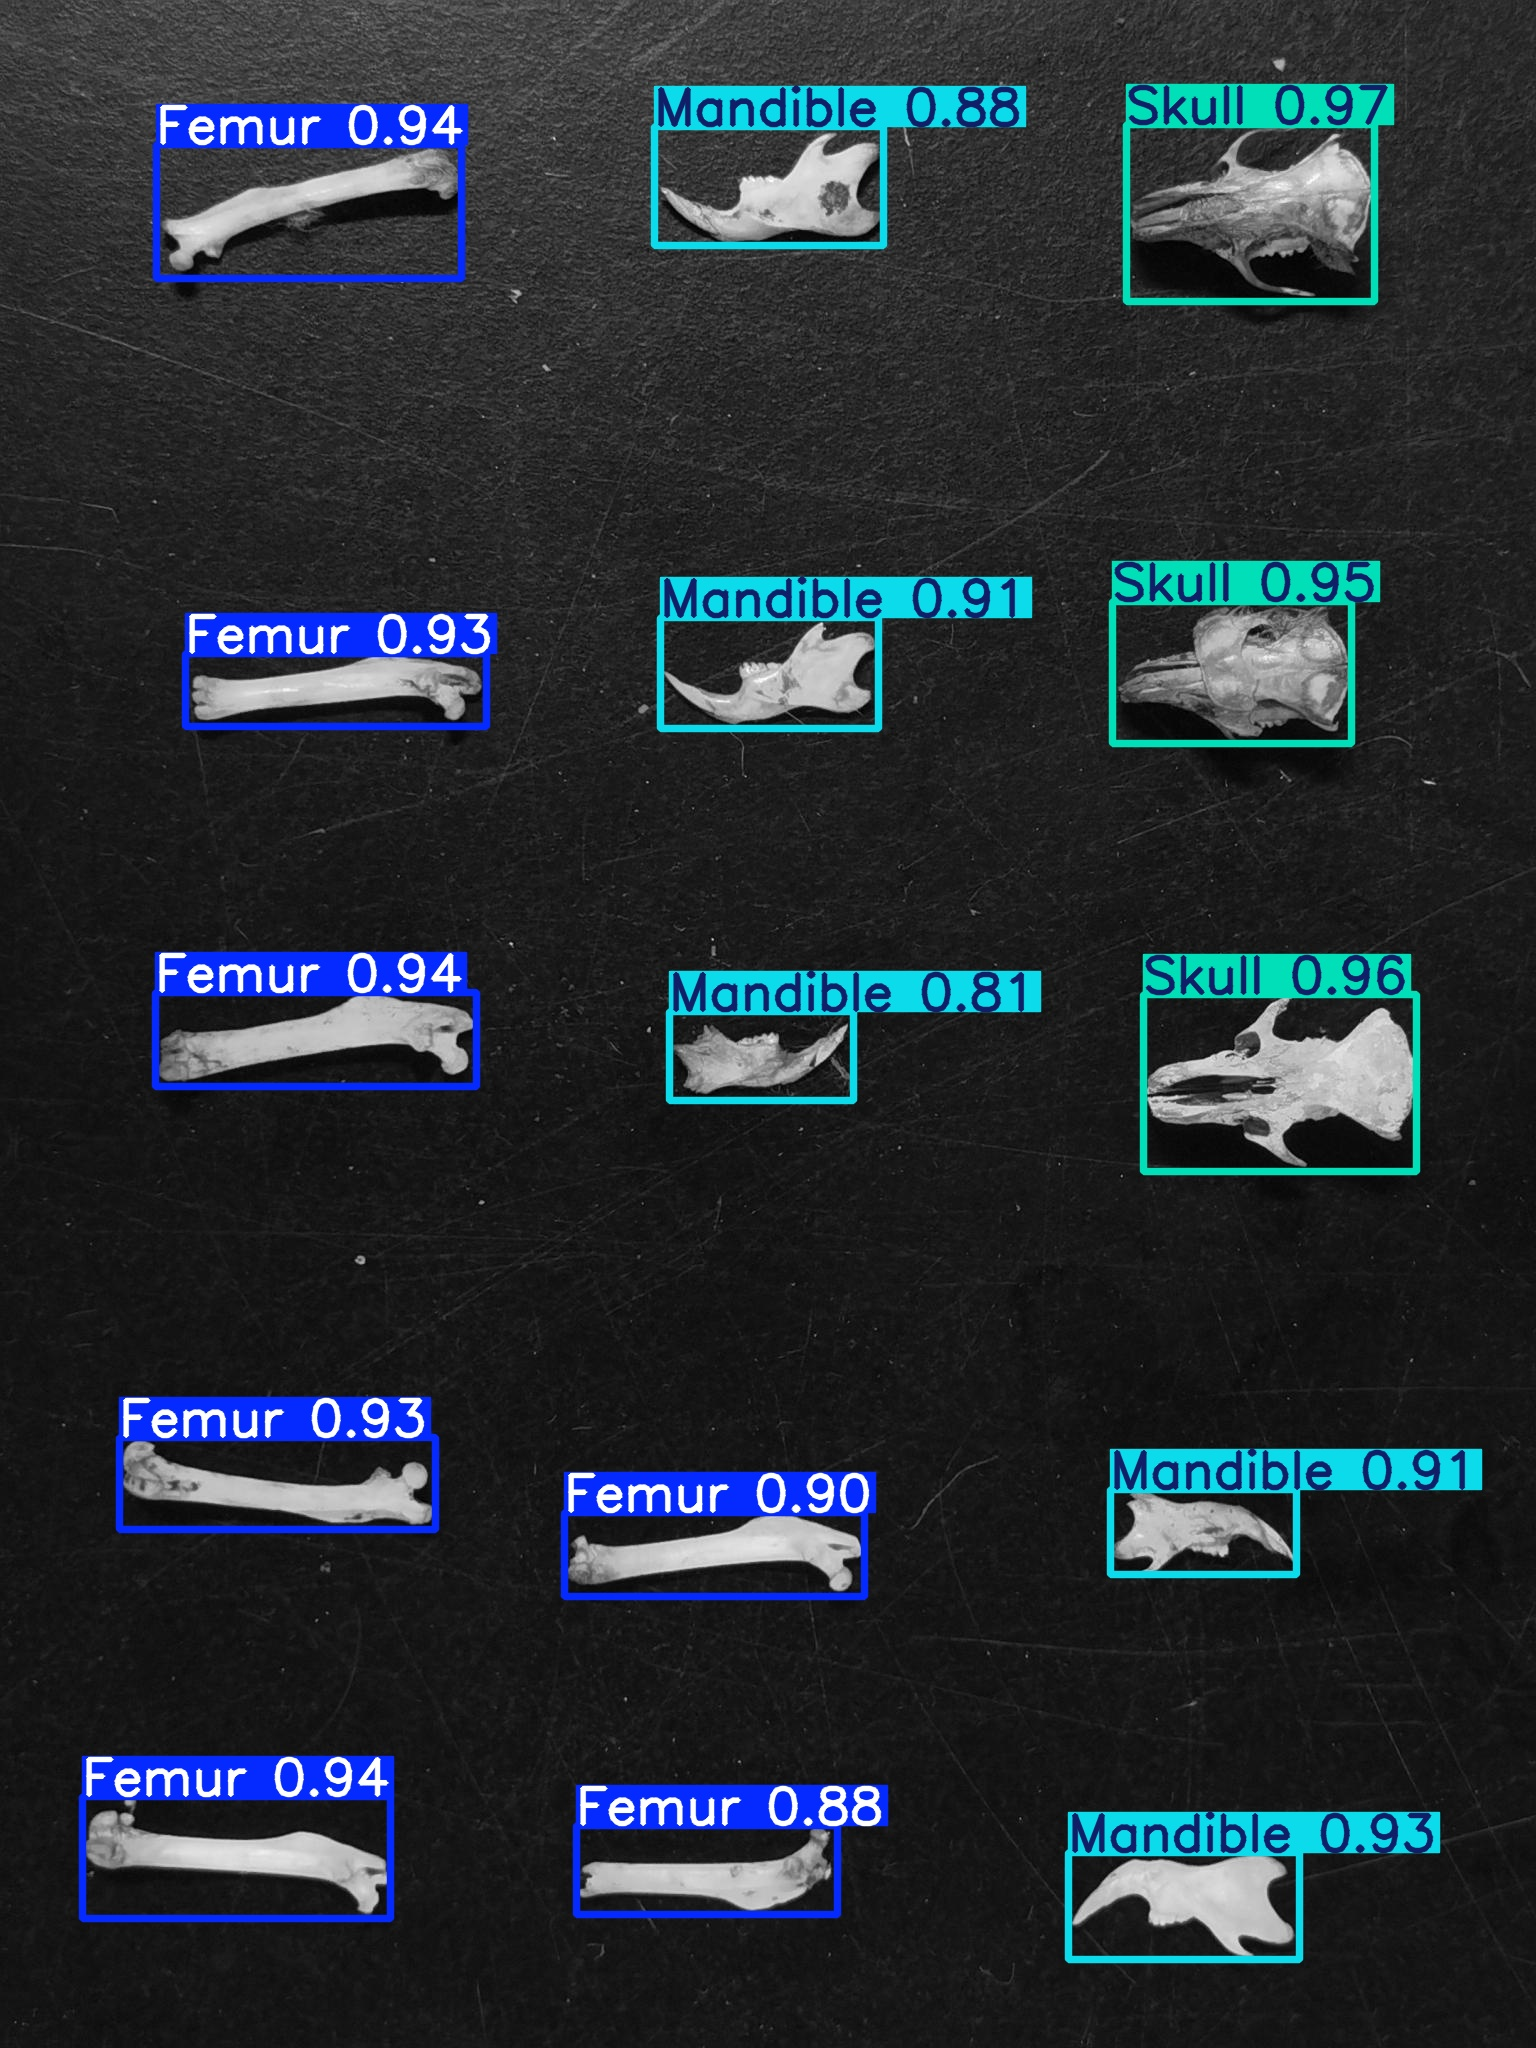

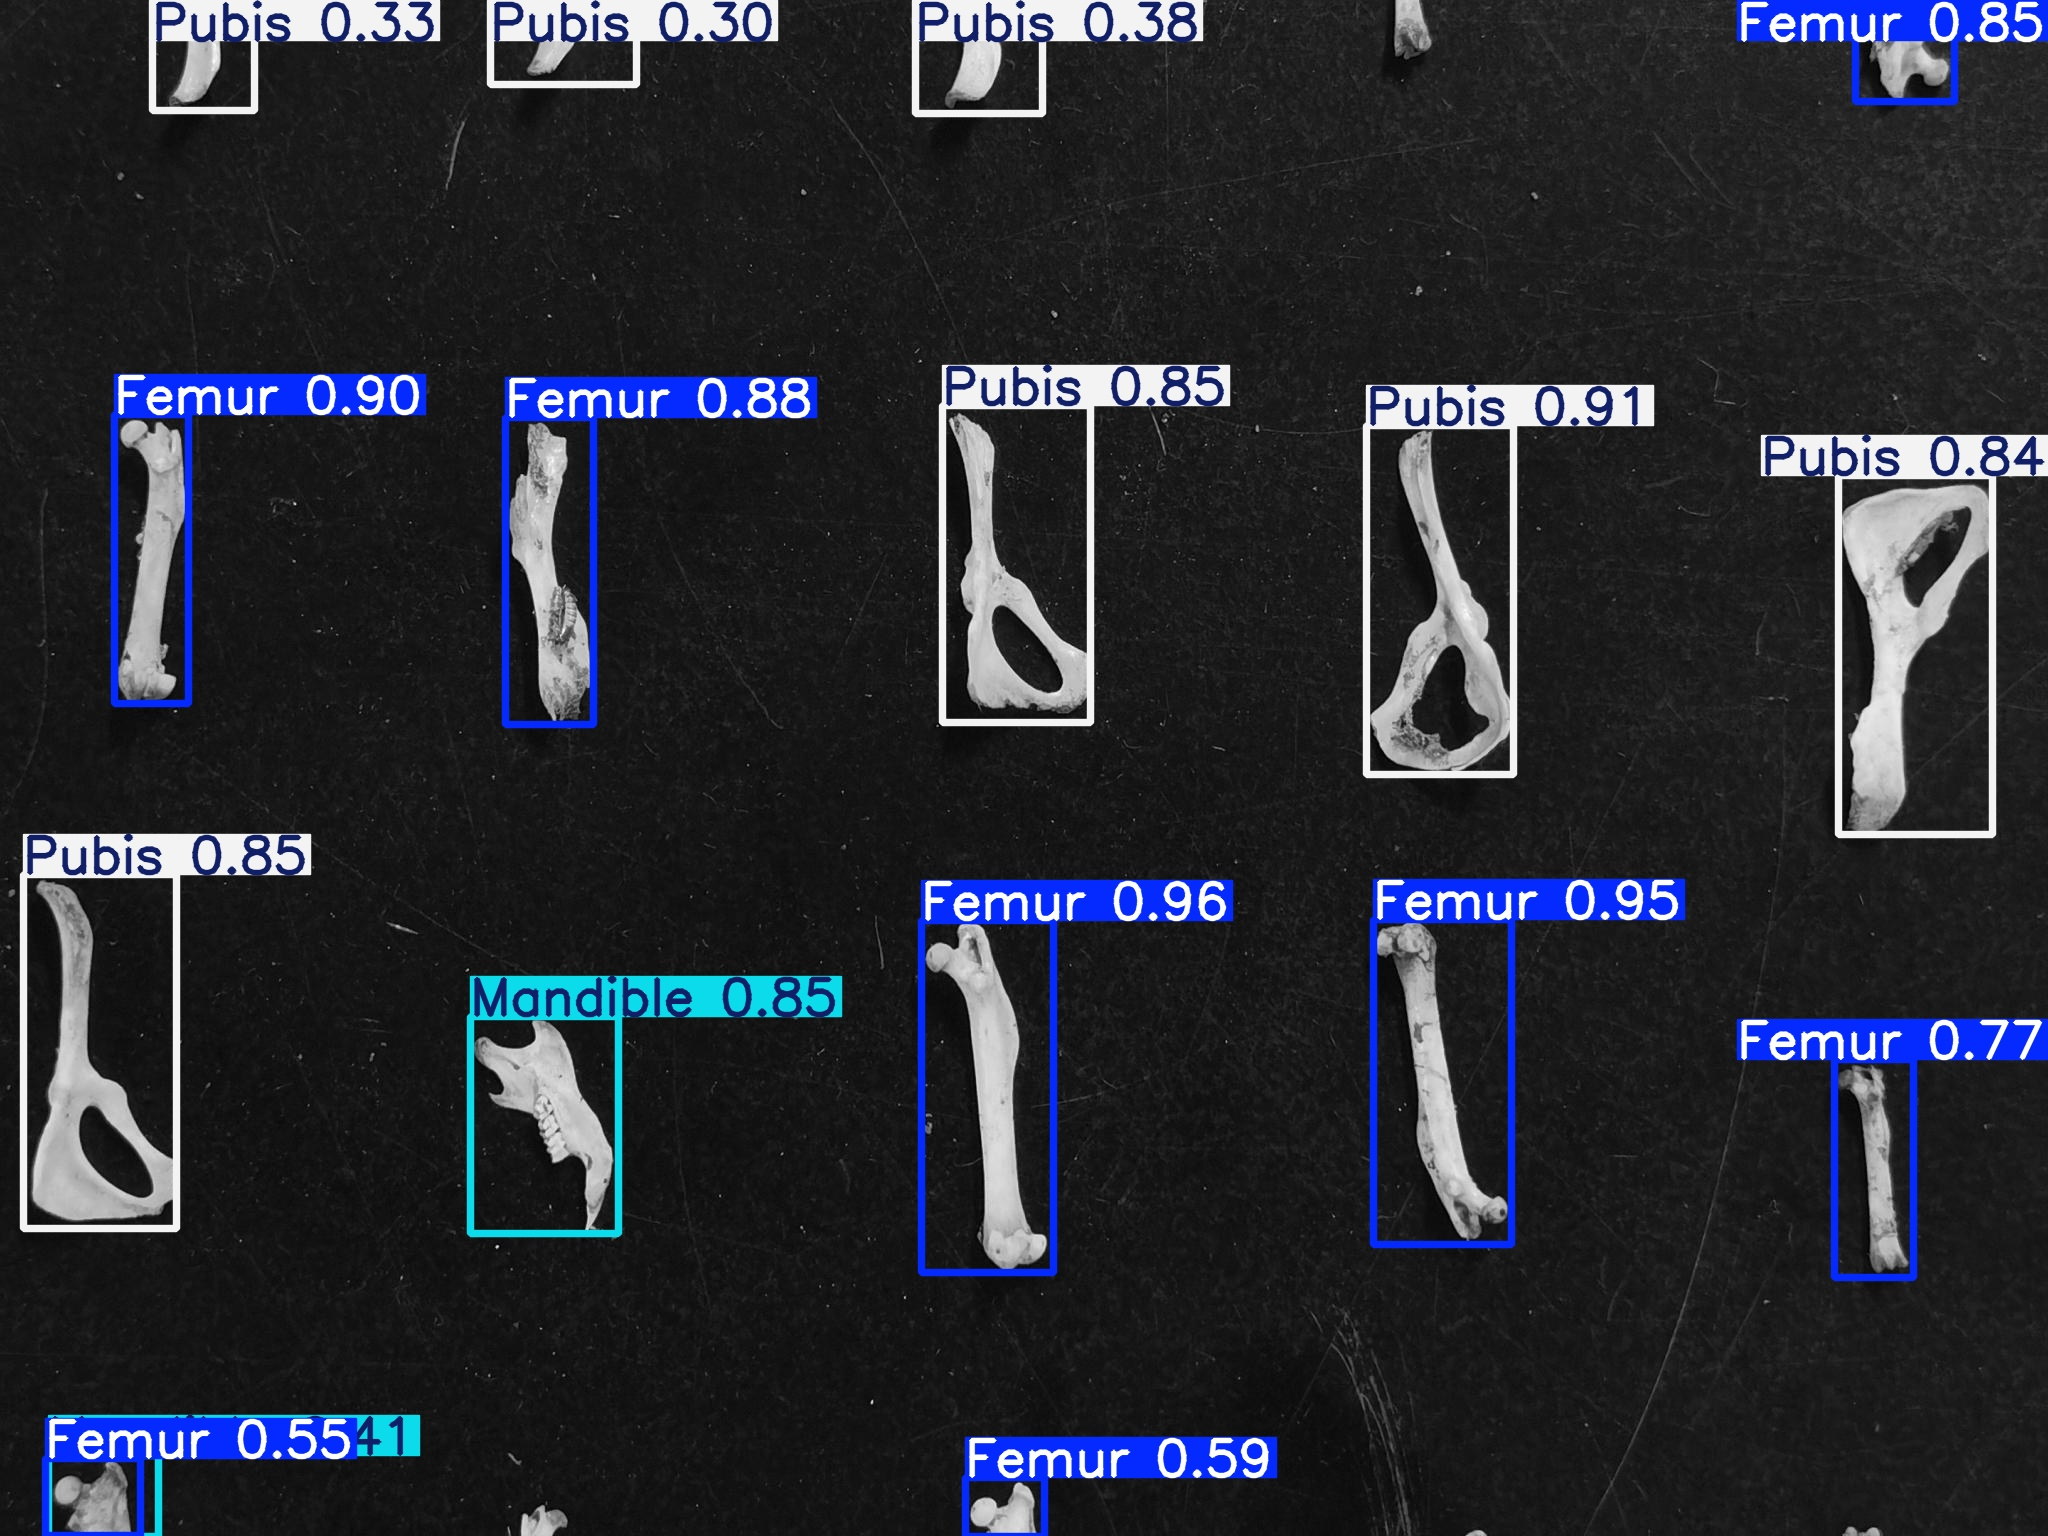

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")